# Baseline Modeling — Early Prediction of Prolonged ICU Stay (v1)

**Objective.** Build a transparent baseline model to estimate risk of prolonged ICU length of stay (LOS) using **only data available in the first 24 hours of the ICU stay** (anti-leakage rule).

**Dataset.** `data/processed/icu_stay_modeling_24h_v1.csv` (one row per `stay_id`, derived from MIMIC-IV Demo).

**Outcome.** `prolonged_los_8d` = 1 if ICU LOS ≥ 8 days, else 0.  
*Note:* This threshold is a pragmatic QI-style definition for this course project; it will be sensitivity-tested later (e.g., 7/10/14 days) and/or justified with literature.

**Evaluation approach.** Primary evaluation uses **grouped cross-validation by `subject_id`** to avoid leakage across multiple ICU stays from the same patient.

## Step 0) Setup

In [14]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GroupKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve

## Step 1) Load data + basic integrity checks
- one row per stay
- prevalence (expect ~16 positives / 140 total)
- no null stay_id

In [15]:
data_path = Path("../data/processed/icu_stay_modeling_24h_v1.csv")
df = pd.read_csv(data_path)

df.shape, df["stay_id"].nunique(), df["prolonged_los_8d"].value_counts(dropna=False)

# Hard sanity checks (fail fast)
assert df["stay_id"].notna().all(), "stay_id has nulls"
assert df["stay_id"].nunique() == len(df), "duplicate stay_id rows detected"
assert set(df["prolonged_los_8d"].unique()).issubset({0, 1}), "target must be 0/1"

# Quick view: how many ICU stays per subject?
stays_per_subject = df.groupby("subject_id")["stay_id"].nunique().sort_values(ascending=False)
stays_per_subject.head(10)

subject_id
10020740    5
10002428    4
10014354    4
10017492    3
10019003    3
10015931    3
10023117    3
10016742    3
10039708    3
10003400    3
Name: stay_id, dtype: int64

## Step 2) Define target + feature sets (drop audit-only)

### Audit-only columns to drop from training:

- `subject_id`, `hadm_id`, `stay_id`

- `intime`, `outtime`

- `los_days`

- `last_careunit` (potential leakage)

In [16]:
target = "prolonged_los_8d"

audit_cols = [
    "subject_id","hadm_id","stay_id",
    "intime","outtime","los_days",
    "last_careunit",
]

X = df.drop(columns=[target] + [c for c in audit_cols if c in df.columns])
y = df[target].astype(int)

X.columns.tolist(), X.shape

(['first_careunit',
  'admission_type',
  'n_chartevents_6h',
  'n_chartevents_24h',
  'missing_core_vitals_24h_count',
  'hr_first',
  'hr_mean',
  'hr_min',
  'hr_max',
  'hr_last',
  'rr_first',
  'rr_mean',
  'rr_min',
  'rr_max',
  'rr_last',
  'spo2_first',
  'spo2_mean',
  'spo2_min',
  'spo2_max',
  'spo2_last',
  'temp_first',
  'temp_mean',
  'temp_min',
  'temp_max',
  'temp_last',
  'map_first',
  'map_mean',
  'map_min',
  'map_max',
  'map_last'],
 (140, 30))

## Step 3) Decide CV strategy (subject-level leakage check)

In [17]:
# Group-aware leakage control: if subjects repeat, we should not split them across folds
groups = df["subject_id"].astype(int).values

n_rows = len(df)
n_stays = df["stay_id"].nunique()
n_subjects = df["subject_id"].nunique()
extra = n_stays - n_subjects

print({"n_rows": n_rows, "n_stays": n_stays, "n_subjects": n_subjects, "extra_stays_beyond_one": extra})

# Show the repeat structure (useful to justify group CV in the writeup)
repeat_subjects = (
    df.groupby("subject_id")["stay_id"]
      .nunique()
      .reset_index(name="n_stays")
      .query("n_stays > 1")
      .sort_values("n_stays", ascending=False)
)
repeat_subjects.head(15)

{'n_rows': 140, 'n_stays': 140, 'n_subjects': 100, 'extra_stays_beyond_one': 40}


,subject_id,n_stays
58,10020740,5
3,10002428,4
35,10014354,4
39,10015931,3
41,10016742,3
7,10003400,3
49,10019003,3
70,10023117,3
43,10017492,3
96,10039708,3


In [18]:
# Prefer stratified *group* k-fold (best of both worlds).
# If your sklearn doesn't have it, fall back to GroupKFold (document the limitation).
try:
    from sklearn.model_selection import StratifiedGroupKFold
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    cv_groups = groups
    cv_name = "StratifiedGroupKFold"
except Exception:
    cv = GroupKFold(n_splits=5)
    cv_groups = groups
    cv_name = "GroupKFold (fallback; not stratified)"

print("CV strategy:", cv_name)

CV strategy: StratifiedGroupKFold


## Step 4) Preprocessing pipeline
Identify categorical vs numeric:

In [19]:
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

cat_cols, num_cols[:10], len(num_cols)

(['first_careunit', 'admission_type'],
 ['n_chartevents_6h',
  'n_chartevents_24h',
  'missing_core_vitals_24h_count',
  'hr_first',
  'hr_mean',
  'hr_min',
  'hr_max',
  'hr_last',
  'rr_first',
  'rr_mean'],
 28)

In [20]:
numeric_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
)

## Step 5) Baseline Model (logistic regression)
Use class_weight balanced because 16 positives.

In [21]:
def make_logreg(class_weight=None):
    model = LogisticRegression(
        max_iter=5000,
        solver="liblinear",
        class_weight=class_weight,
    )
    return Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model),
    ])

clf_plain = make_logreg(class_weight=None)              # baseline calibration-friendly
clf_bal   = make_logreg(class_weight="balanced")        # baseline recall-friendly

## 6) Cross-validation metrics (ROC AUC + PR AUC + Brier)

In [22]:
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "brier": "neg_brier_score",
}

def cv_run(clf, name):
    scores = cross_validate(
        clf, X, y,
        cv=cv,
        groups=cv_groups,
        scoring=scoring,
        return_train_score=False,
        error_score="raise",
    )
    return pd.DataFrame({
        "model": name,
        "roc_auc": scores["test_roc_auc"],
        "pr_auc": scores["test_pr_auc"],
        "brier": -scores["test_brier"],
    })

res_plain = cv_run(clf_plain, "LogReg (no class_weight)")
res_bal   = cv_run(clf_bal,   "LogReg (class_weight=balanced)")

results = pd.concat([res_plain, res_bal], ignore_index=True)
results.groupby("model")[["roc_auc","pr_auc","brier"]].agg(["mean","std","min","max"])

roc_auc                                \
                                    mean       std       min       max   
model                                                                    
LogReg (class_weight=balanced)  0.705248  0.117484  0.522727  0.833333   
LogReg (no class_weight)        0.679179  0.110156  0.522727  0.833333   

                                  pr_auc                                \
                                    mean       std       min       max   
model                                                                    
LogReg (class_weight=balanced)  0.367991  0.100689  0.273133  0.493590   
LogReg (no class_weight)        0.355649  0.090963  0.258657  0.457576   

                                   brier                                
                                    mean       std       min       max  
model                                                                   
LogReg (class_weight=balanced)  0.153059  0.056427  0.095870  0.246581  
LogReg (no class_weight)        0.113130  0.031840  0.075815  0.153402

## Step 7) Baseline comparator: “predict prevalence”

In [23]:
prevalence = y.mean()
brier_naive = brier_score_loss(y, np.full_like(y, prevalence, dtype=float))
pr_naive = prevalence  # expected AP for a non-informative classifier is ~prevalence

prevalence, brier_naive, pr_naive

(0.11428571428571428, 0.10122448979591836, 0.11428571428571428)

## Step 8) Fit on data + Inspect coefficients interpretability

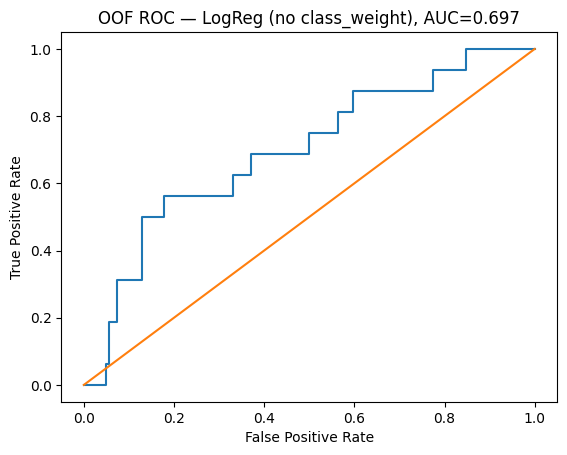

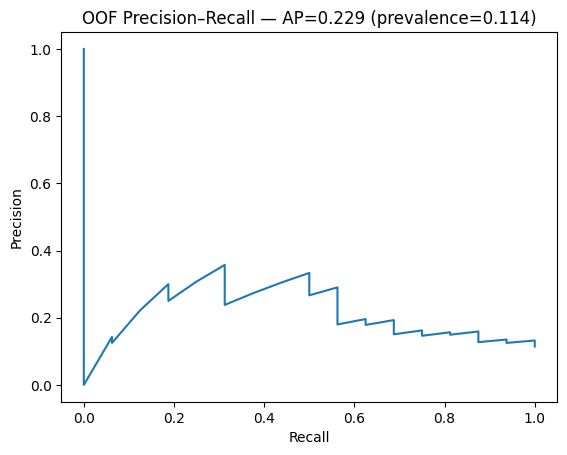

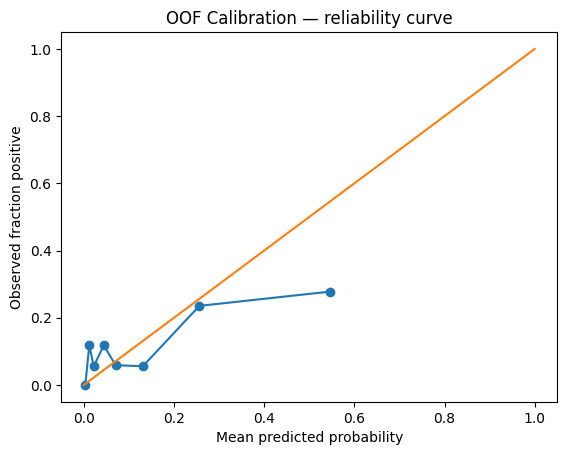

In [24]:
# Out-of-fold probabilities (unbiased per-row prediction)
oof_proba = cross_val_predict(
    clf_plain, X, y,
    cv=cv,
    groups=cv_groups,
    method="predict_proba"
)[:, 1]

# ROC
fpr, tpr, _ = roc_curve(y, oof_proba)
roc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"OOF ROC — LogReg (no class_weight), AUC={roc:.3f}")
plt.show()

# PR
prec, rec, _ = precision_recall_curve(y, oof_proba)
ap = average_precision_score(y, oof_proba)
plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"OOF Precision–Recall — AP={ap:.3f} (prevalence={prevalence:.3f})")
plt.show()

# Calibration curve
frac_pos, mean_pred = calibration_curve(y, oof_proba, n_bins=8, strategy="quantile")
plt.figure()
plt.plot(mean_pred, frac_pos, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed fraction positive")
plt.title("OOF Calibration — reliability curve")
plt.show()

**Interpretation note:** Numeric features are standardized, so coefficients correspond to a 1-SD change. Coefficients are associative and unstable under small N; treat as directional, not definitive.

In [25]:
from IPython.display import display

# Fit on full data for interpretability only (not unbiased performance)
clf_plain.fit(X, y)

# Feature names after preprocessing (works when you use get_feature_names_out)
feature_names = clf_plain.named_steps["preprocess"].get_feature_names_out()
coefs = clf_plain.named_steps["model"].coef_.ravel()

coef_df = (
    pd.DataFrame({"feature": feature_names, "coef": coefs})
      .sort_values("coef", ascending=False)
)

display(coef_df.head(15))
display(coef_df.tail(15))

,feature,coef
1,num__n_chartevents_24h,1.118752
4,num__hr_mean,0.883376
24,num__map_mean,0.701009
13,num__spo2_first,0.601737
9,num__rr_mean,0.587899
7,num__hr_last,0.569776
29,cat__first_careunit_Coronary Care Unit (CCU),0.474137
20,num__temp_min,0.461557
40,cat__admission_type_OBSERVATION ADMIT,0.348606
37,cat__admission_type_DIRECT EMER.,0.324763


,feature,coef
33,cat__first_careunit_Neuro Stepdown,-0.116721
16,num__spo2_max,-0.135877
17,num__spo2_last,-0.154962
10,num__rr_min,-0.193016
2,num__missing_core_vitals_24h_count,-0.316660
18,num__temp_first,-0.333629
38,cat__admission_type_ELECTIVE,-0.416491
39,cat__admission_type_EW EMER.,-0.499634
5,num__hr_min,-0.645258
41,cat__admission_type_SURGICAL SAME DAY ADMISSION,-0.722969


In [26]:
out_dir = Path("../outputs/tables")
out_dir.mkdir(parents=True, exist_ok=True)

results.to_csv(out_dir / "model_v1_cv_metrics_by_fold.csv", index=False)

summary_tbl = results.groupby("model")[["roc_auc","pr_auc","brier"]].agg(["mean","std","min","max"])
summary_tbl.to_csv(out_dir / "model_v1_cv_metrics_summary.csv")

coef_df.to_csv(out_dir / "model_v1_logreg_coefficients.csv", index=False)

pd.DataFrame({"oof_proba": oof_proba, "y": y}).to_csv(out_dir / "model_v1_oof_predictions.csv", index=False)